In [1]:
import copernicusmarine

In [2]:
ds_sal = copernicusmarine.open_dataset(dataset_id='cmems_mod_med_phy-sal_my_4.2km_P1D-m')

INFO - 2026-04-23T14:38:56Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:

  lfortunato


Copernicus Marine password:

  ········


INFO - 2026-04-23T14:39:06Z - Selected dataset version: "202511"
INFO - 2026-04-23T14:39:06Z - Selected dataset part: "default"


In [3]:
ds_sal

<xarray.Dataset> Size: 3TB
Dimensions:    (depth: 141, latitude: 380, longitude: 1016, time: 14335)
Coordinates:
  * depth      (depth) float32 564B 1.018 3.166 5.465 ... 5.646e+03 5.754e+03
  * latitude   (latitude) float32 2kB 30.19 30.23 30.27 ... 45.9 45.94 45.98
  * longitude  (longitude) float32 4kB -6.0 -5.958 -5.917 ... 36.21 36.25 36.29
  * time       (time) datetime64[ns] 115kB 1987-01-01 1987-01-02 ... 2026-03-31
Data variables:
    so         (time, depth, latitude, longitude) float32 3TB dask.array<chunksize=(100, 2, 380, 1016), meta=np.ndarray>
Attributes:
    Conventions:               CF-1.0
    bulletin_date:             20230707
    bulletin_type:             interim
    comment:                   Please check in CMEMS catalogue the INFO secti...
    contact:                   servicedesk.cmems@mercator-ocean.eu
    field_type:                daily_mean_centered_at_time_field
    institution:               Centro Euro-Mediterraneo sui Cambiamenti Clima...
    references:                Escudier, R., Clementi, E., Omar, M., Cipollon...
    source:                    MFS E3R1I
    title:                     Salinity (3D) - Daily Mean
    copernicusmarine_version:  2.3.0

In [4]:
import hvplot.xarray
import panel as pn
pn.extension()

In [5]:
da_sal = ds_sal['so'].sel(depth=0, time='2026-03-31 00:00', method='nearest').load()

In [6]:
da_sal.nbytes / 1e6  # MB

1.54432

In [7]:
import cmocean
da_sal.hvplot(x='longitude', y='latitude', rasterize=True, geo=True, cmap='cmo.haline', tiles='OSM', clabel='Practical Salinity (PSU)')

:DynamicMap   []
   :Overlay
      .WMTS.I  :WMTS   [Longitude,Latitude]
      .Image.I :Image   [longitude,latitude]   (salinity)

In [8]:
# Gulf of Lion subset
da_gol_sal = da_sal.sel(
    longitude=slice(2.0, 6.5),
    latitude=slice(41.0, 44.5)
)
da_gol_sal

<xarray.DataArray 'so' (latitude: 84, longitude: 109)> Size: 37kB
array([[38.173332, 38.19159 , 38.208565, ..., 37.814163, 37.780567,
        37.752136],
       [38.157658, 38.178577, 38.20097 , ..., 37.80744 , 37.774925,
        37.748165],
       [38.136654, 38.154808, 38.174706, ..., 37.808197, 37.7768  ,
        37.752293],
       ...,
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan]], shape=(84, 109), dtype=float32)
Coordinates:
    depth      float32 4B 1.018
  * latitude   (latitude) float32 336B 41.02 41.06 41.1 ... 44.4 44.44 44.48
  * longitude  (longitude) float32 436B 2.0 2.042 2.083 ... 6.417 6.458 6.5
    time       datetime64[ns] 8B 2026-03-31
Attributes:
    long_name:      salinity
    standard_name:  sea_water_salinity
    units:          0.001
    valid_max:      42.0
    valid_min:      1.0

In [9]:
import geoviews.feature as gf
import numpy as np

vmin = float(da_gol_sal.min())
vmax = float(da_gol_sal.max())
levels = [round(v, 2) for v in np.linspace(vmin, vmax, 10)]

raster   = da_gol_sal.hvplot(x='longitude', y='latitude', rasterize=True, geo=True, cmap='cmo.haline', tiles='ESRI', clabel='Practical Salinity (PSU)')
contours = da_gol_sal.hvplot.contour(x='longitude', y='latitude', geo=True, levels=levels, line_width=0.8, cmap='gray')


raster * contours * coast

:DynamicMap   []
   :Overlay
      .WMTS.I      :WMTS   [Longitude,Latitude]
      .Image.I     :Image   [longitude,latitude]   (salinity)
      .Contours.I  :Contours   [longitude,latitude]   (salinity)
      .Coastline.I :Feature   [Longitude,Latitude]

In [10]:
last_time = ds_sal.time[-1].values
print(f"Last available date: {last_time}")

da_gol_sal_3d = (
    ds_sal['so']
    .sel(time=last_time, method='nearest')
    .sel(longitude=slice(2.0, 6.5), latitude=slice(41.0, 44.5))
    .load()
)
da_gol_sal_3d

Last available date: 2026-03-31T00:00:00.000000000


<xarray.DataArray 'so' (depth: 141, latitude: 84, longitude: 109)> Size: 5MB
array([[[38.173332, 38.19159 , 38.208565, ..., 37.814163, 37.780567,
         37.752136],
        [38.157658, 38.178577, 38.20097 , ..., 37.80744 , 37.774925,
         37.748165],
        [38.136654, 38.154808, 38.174706, ..., 37.808197, 37.7768  ,
         37.752293],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[38.17264 , 38.19079 , 38.20748 , ..., 37.814182, 37.780575,
         37.75213 ],
        [38.15688 , 38.17776 , 38.199993, ..., 37.80742 , 37.7749  ,
         37.74813 ],
        [38.13554 , 38.15369 , 38.173603, ..., 37.808147, 37.77675 ,
         37.75224 ],
...
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], shape=(141, 84, 109), dtype=float32)
Coordinates:
  * depth      (depth) float32 564B 1.018 3.166 5.465 ... 5.646e+03 5.754e+03
  * latitude   (latitude) float32 336B 41.02 41.06 41.1 ... 44.4 44.44 44.48
  * longitude  (longitude) float32 436B 2.0 2.042 2.083 ... 6.417 6.458 6.5
    time       datetime64[ns] 8B 2026-03-31
Attributes:
    long_name:      salinity
    standard_name:  sea_water_salinity
    units:          0.001
    valid_max:      42.0
    valid_min:      1.0

In [11]:
vmin_3d = float(np.nanmin(da_gol_sal_3d.values))
vmax_3d = float(np.nanmax(da_gol_sal_3d.values))
print(f"da_gol_sal_3d  →  min = {vmin_3d:.3f} PSU   max = {vmax_3d:.3f} PSU")

da_gol_sal_3d  →  min = 36.373 PSU   max = 38.758 PSU


In [12]:
da_gol_sal_3d.hvplot(
    x='longitude', y='latitude',
    groupby='depth',
    rasterize=True, geo=True,
    cmap='cmo.haline', tiles='ESRI',
    clabel='Practical Salinity (PSU)',
    clim=(vmin_3d, vmax_3d),
    widget_location='bottom'
)

Column
    [0] HoloViews(DynamicMap, sizing_mode='fixed', widget_location='bottom')
    [1] WidgetBox(align=('center', 'end'))
        [0] DiscreteSlider(name='Depth (m)', options={'1.0182': np.float32(1.01...}, value=np.float32(1.0182366))

In [13]:
import pandas as pd

da_sal_march = (
    ds_sal['so']
    .sel(time=slice('2026-03-21', '2026-03-31'))
    .sel(longitude=slice(2.0, 6.5), latitude=slice(41.0, 44.5))
    .sel(depth=[0, 500, 1000], method='nearest')
    .load()
)
depths_actual = da_sal_march.depth.values

time_values = [pd.Timestamp(t).strftime('%Y-%m-%d') for t in da_sal_march.time.values]
time_slider = pn.widgets.DiscreteSlider(name='Date (March 2026)', options=time_values, value=time_values[0])

opts = dict(
    x='longitude', y='latitude',
    rasterize=True, geo=True,
    cmap='cmo.haline',
    clabel='Practical Salinity (PSU)',
    tiles='ESRI',
    width=400, height=350,
)

@pn.depends(time_slider)
def three_maps(time_str):
    da_t = da_sal_march.sel(time=time_str)
    m0    = da_t.sel(depth=depths_actual[0]).hvplot(title=f'Depth ≈ {depths_actual[0]:.0f} m',  **opts, clim=(vmin_3d, vmax_3d))
    m500  = da_t.sel(depth=depths_actual[1]).hvplot(title=f'Depth ≈ {depths_actual[1]:.0f} m',  **opts, clim=(vmin_3d, vmax_3d))
    m1000 = da_t.sel(depth=depths_actual[2]).hvplot(title=f'Depth ≈ {depths_actual[2]:.0f} m', **opts, clim=(vmin_3d, vmax_3d))
    return pn.Row(m0, m500, m1000)

pn.Column(time_slider, three_maps)

Column
    [0] DiscreteSlider(name='Date (March 2026)', options=['2026-03-21', ...], value='2026-03-21')
    [1] ParamFunction(function, _pane=Row, defer_load=False)

In [14]:
da_sal_point = da_sal_march.sel(longitude=5.0, latitude=41.0, method='nearest')

opts_line = dict(
    x='time',
    y='so',
    xlabel='Date',
    ylabel='Practical Salinity (PSU)',
    line_width=2.5,
    grid=True,
    width=400,
    height=350,
    ylim=(vmin_3d, vmax_3d),
)

p0 = da_sal_point.sel(depth=depths_actual[0]).hvplot(
    title='Time series',
    color='crimson',
    label=f'{depths_actual[0]:.0f} m',
    legend='bottom_left',
    **opts_line
)
p500 = da_sal_point.sel(depth=depths_actual[1]).hvplot(
    color='seagreen',
    label=f'{depths_actual[1]:.0f} m',
    **opts_line
)
p1000 = da_sal_point.sel(depth=depths_actual[2]).hvplot(
    color='royalblue',
    label=f'{depths_actual[2]:.0f} m',
    **opts_line
)

p0 * p500 * p1000

:Overlay
   .Curve.A_1_m    :Curve   [time]   (salinity)
   .Curve.A_493_m  :Curve   [time]   (salinity)
   .Curve.A_1005_m :Curve   [time]   (salinity)

INFO - 2026-04-23T14:40:03Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:

  lfortunato


Copernicus Marine password:

  ········


INFO - 2026-04-23T14:42:20Z - Selected dataset version: "202511"
INFO - 2026-04-23T14:42:20Z - Selected dataset part: "default"


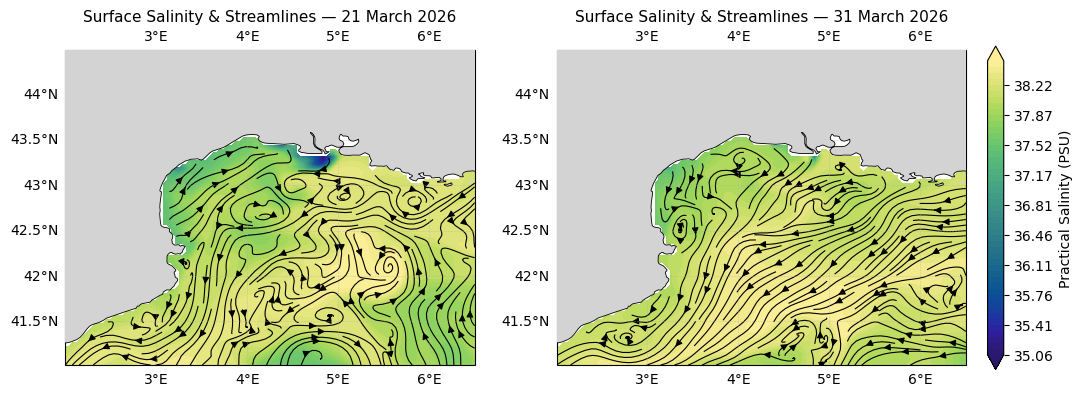

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import numpy as np
import copernicusmarine

DATES = ['2026-03-21', '2026-03-31']
TITLES = ['21 March 2026', '31 March 2026']

slices = [da_sal_march.sel(time=d, depth=depths_actual[0]) for d in DATES]

vmin = float(min(s.min() for s in slices))
vmax = float(max(s.max() for s in slices))
levels = np.linspace(vmin, vmax, 50)

lon = slices[0].longitude.values
lat = slices[0].latitude.values

# --- Carica correnti per le streamlines ---
ds_cur = copernicusmarine.open_dataset(dataset_id='cmems_mod_med_phy-cur_my_4.2km_P1D-m')
cur_data = []
for date in DATES:
    u = ds_cur['uo'].sel(depth=0, time=date, method='nearest').sel(longitude=slice(2.0, 6.5), latitude=slice(41.0, 44.5)).load()
    v = ds_cur['vo'].sel(depth=0, time=date, method='nearest').sel(longitude=slice(2.0, 6.5), latitude=slice(41.0, 44.5)).load()
    cur_data.append({'u': u.values, 'v': v.values})

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    subplot_kw={'projection': ccrs.PlateCarree()},
)

for ax, da_t, cur, title in zip(axes, slices, cur_data, TITLES):
    cf = ax.contourf(
        lon, lat, da_t.values,
        levels=levels,
        cmap='cmo.haline',
        transform=ccrs.PlateCarree(),
        extend='both',
    )
    ax.streamplot(
        lon, lat, cur['u'], cur['v'],
        transform=ccrs.PlateCarree(),
        density=2,
        linewidth=0.8,
        color='black',
        arrowsize=1.0,
    )
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=4)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle='--', alpha=0.6)
    gl.right_labels = False
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
    ax.set_title(f'Surface Salinity & Streamlines — {title}', fontsize=11)

cbar = fig.colorbar(cf, ax=axes, label='Practical Salinity (PSU)', shrink=0.7, pad=0.02)
cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import numpy as np
import copernicusmarine

DATES = ['2026-03-21', '2026-03-31']
TITLES = ['21 March 2026', '31 March 2026']

slices = [da_sal_march.sel(time=d, depth=depths_actual[0]) for d in DATES]

vmin = float(min(s.min() for s in slices))
vmax = float(max(s.max() for s in slices))
levels = np.linspace(vmin, vmax, 50)

lon = slices[0].longitude.values
lat = slices[0].latitude.values

# --- Carica correnti per i quiver ---
ds_cur = copernicusmarine.open_dataset(dataset_id='cmems_mod_med_phy-cur_my_4.2km_P1D-m')
cur_data = []
for date in DATES:
    u = ds_cur['uo'].sel(depth=0, time=date, method='nearest').sel(longitude=slice(2.0, 6.5), latitude=slice(41.0, 44.5)).load()
    v = ds_cur['vo'].sel(depth=0, time=date, method='nearest').sel(longitude=slice(2.0, 6.5), latitude=slice(41.0, 44.5)).load()
    cur_data.append({'u': u.values, 'v': v.values})

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    subplot_kw={'projection': ccrs.PlateCarree()},
)

step = 3
ref_speed = 0.3
ref_lon, ref_lat = 5.8, 43.9

for ax, da_t, cur, title in zip(axes, slices, cur_data, TITLES):
    cf = ax.contourf(
        lon, lat, da_t.values,
        levels=levels,
        cmap='cmo.haline',
        transform=ccrs.PlateCarree(),
        extend='both',
    )
    ax.quiver(
        lon[::step], lat[::step],
        cur['u'][::step, ::step], cur['v'][::step, ::step],
        transform=ccrs.PlateCarree(),
        scale=10, width=0.003,
        color='white', alpha=0.8,
    )
    ax.quiver(ref_lon, ref_lat, ref_speed, 0,
              transform=ccrs.PlateCarree(), scale=10, width=0.003,
              color='black', zorder=10)
    ax.text(ref_lon + 0.35, ref_lat, f'{ref_speed} m/s',
            transform=ccrs.PlateCarree(), fontsize=9,
            va='center', ha='left', color='black', zorder=11,
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1))
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=4)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle='--', alpha=0.6)
    gl.right_labels = False
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
    ax.set_title(f'Surface Salinity & Current Vectors — {title}', fontsize=11)

cbar = fig.colorbar(cf, ax=axes, label='Practical Salinity (PSU)', shrink=0.7, pad=0.02)
cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.show()

INFO - 2026-04-23T14:42:38Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: